# ÉTAPE 1 – Compréhension du dataset

## Programme d'analyse

- Analyse de tables
- Identification des structures et types de donnees
- Detection des problemes de qualite
- Visualisation des resultats

2. Importation des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os



 ### Chargement des données

In [ ]:
# Charger les données
combat_attributes = pd.read_csv('Palworld_Data--Palu combat attribute table.csv',skiprows=1)
refresh_level = pd.read_csv('Palworld_Data--Palu refresh level.csv')
job_skills = pd.read_csv('Palworld_Data-Palu Job Skills Table.csv',skiprows=1)
tower_boss = pd.read_csv('Palworld_Data-Tower BOSS attribute comparison.csv')
ordinary_boss = pd.read_csv('Palworld_Data-comparison of ordinary BOSS attributes.csv',skiprows=3)
hidden_attributes = pd.read_csv('Palworld_Data-hide pallu attributes.csv')


### Nettoyer chaque table



#### a. Table combat_attributes
- Traiter les valeurs manquantes
- Normaliser les colonnes
- Supprimer les doublons

In [ ]:

# Remplacer les valeurs manquantes par des valeurs par défaut
combat_attributes.fillna({
    'HP': 0,
    'melee attack': 0,
    'defense': 0,
    'support': 0,
    'Speed of work': 0
}, inplace=True)

# Normaliser les noms de colonnes
combat_attributes.columns = [col.strip().lower().replace(' ', '_') for col in combat_attributes.columns]
print(combat_attributes["catch_rate"])
# Supprimer les doublons
combat_attributes.drop_duplicates(inplace=True)

# Vérifier les données nettoyées
print(combat_attributes.head())
print(combat_attributes.columns)


0      150%
1      150%
2      150%
3       90%
4      110%
       ... 
133    100%
134    100%
135    100%
136    100%
137    100%
Name: catch_rate, Length: 138, dtype: object
   id    chinese_name      name    codename overridenametextid  nameprefixid  \
0   1     Mian Youyou   Lamball   SheepBall                NaN           NaN   
1   2     Naughty cat   Cattiva     PinkCat                NaN           NaN   
2   3    Pipi Chicken   Chikipi  ChickenPal                NaN           NaN   
3   4  green leaf rat   Lifmunk   Carbunclo                NaN           NaN   
4   5      tinder fox  Foxparks   Kitsunebi                NaN           NaN   

  overridepartnerskilltextid  ispal                    tribe     bpclass  ...  \
0                        NaN   True   EPalTribeID::SheepBall   SheepBall  ...   
1                        NaN   True     EPalTribeID::PinkCat     PinkCat  ...   
2                        NaN   True  EPalTribeID::ChickenPal  ChickenPal  ...   
3                 

###  b. Table refresh_level

- Supprimer les colonnes inutiles
- Traiter les valeurs manquantes
- Normaliser les colonnes


In [ ]:
# Charger les données en ignorant les lignes inutiles
refresh_level = pd.read_csv('Palworld_Data--Palu refresh level.csv')

# Vérifier les noms de colonnes
print("Noms de colonnes avant nettoyage :")
print(refresh_level.columns)

# Normaliser les noms de colonnes
refresh_level.columns = [col.strip().lower().replace(' ', '_') for col in refresh_level.columns]

# Vérifier les noms de colonnes après normalisation
print("Noms de colonnes après nettoyage :")
print(refresh_level.columns)

# Vérifier les premières lignes pour identifier les colonnes correctes
print("Premières lignes du DataFrame :")
print(refresh_level.head())

# Supprimer les colonnes inutiles (ajustez selon vos besoins)
# Ajustez cette liste selon les colonnes qui existent réellement
columns_to_keep = ['id', 'name', 'minimum level', 'maximum level', 'refresh area']

# Vérifiez si les colonnes à garder existent
missing_columns = [col for col in columns_to_keep if col not in refresh_level.columns]
if missing_columns:
    print(f"Colonnes manquantes : {missing_columns}")

# Filtrer les colonnes
# Vous pouvez ajuster cette partie en fonction des colonnes que vous avez identifiées
# Par exemple, si '4.0' correspond à 'id', 'green_leaf_rat' à 'name', etc.
#refresh_level = refresh_level[['id', 'name', 'minimum level', 'maximum level', 'refresh area']]  # Ajustez les noms ici

# Remplacer les valeurs manquantes
refresh_level.fillna({
    'minimum level': 0,
    'maximum level': 0,
    'refresh area': 'Unknown'
}, inplace=True)

# Supprimer les doublons
refresh_level.drop_duplicates(inplace=True)

# Vérifier les données nettoyées
print("Données nettoyées :")
print(refresh_level.head())


Noms de colonnes avant nettoyage :
Index(['id', 'name', 'minimum level', 'maximum level', 'refresh area'], dtype='object')
Noms de colonnes après nettoyage :
Index(['id', 'name', 'minimum_level', 'maximum_level', 'refresh_area'], dtype='object')
Premières lignes du DataFrame :
     id                name  minimum_level  maximum_level   refresh_area
0  12.0        electric_rat            3.0           13.0  random_events
1  12.0          ice agouti           10.0           10.0      grassland
2  13.0  Ye Ni Ni (Special)            2.0           14.0        islands
3  13.0             Ye NiNi            2.0           14.0        islands
4  14.0          Tamamo fox            3.0           13.0      grassland
Colonnes manquantes : ['minimum level', 'maximum level', 'refresh area']
Données nettoyées :
     id                name  minimum_level  maximum_level   refresh_area
0  12.0        electric_rat            3.0           13.0  random_events
1  12.0          ice agouti           10.0   

#### c. Table job_skills
- Traiter les valeurs manquantes
- Normaliser les colonnes
- Supprimer les doublons

In [ ]:
# Remplacer les valeurs manquantes
job_skills.fillna({
    'night shift': False,
    'Total skills': 0,
    'Handling speed': 0
}, inplace=True)

# Normaliser les noms de colonnes
job_skills.columns = [col.strip().lower().replace(' ', '_') for col in job_skills.columns]

# Supprimer les doublons
job_skills.drop_duplicates(inplace=True)

# Vérifier les données nettoyées
print(job_skills.head())


   id english_name    chinese_name volume_size  food_intake night_shift  \
0   1      Lamball     Mian Youyou    smallest            2       False   
1   2      Cattiva     Naughty cat    smallest            2       False   
2   3      Chikipi    Pipi Chicken    smallest            1       False   
3   4      Lifmunk  green leaf rat    smallest            1       False   
4   5     Foxparks      tinder fox    smallest            2       False   

   total_skills  make_a_fire  watering  planting  ...  logging  mining  \
0             3            0         0         0  ...        0       0   
1             4            0         0         0  ...        0       1   
2             2            0         0         0  ...        0       0   
3             5            0         0         1  ...        1       0   
4             1            1         0         0  ...        0       0   

   pharmaceutical  cool_down  pasture  carry  handling_speed  ranch_items  \
0               0          

### d. Table tower_boss
- Traiter les valeurs manquantes
- Normaliser les colonnes
- Supprimer les doublons


In [ ]:
tower_boss=tower_boss.T
tower_boss.columns=tower_boss.iloc[0]
tower_boss.drop(tower_boss.index[0],inplace=True)
print(tower_boss.head())

name                              HP melee attack Remote attack defense  \
victor_&_heterogeneous_griffin  8000          130           200     220   
heterogeneous_griffin            120          130           120     140   
zoe_&_lightning_bear            6000          100           100     100   
lightning_bear                   105          120           100     100   
marcus_&_horus                  6500          100           120     125   

name                           Support experience ratio slow walking speed  \
victor_&_heterogeneous_griffin      90               30                 80   
heterogeneous_griffin               90                1                 80   
zoe_&_lightning_bear               100               30                 80   
lightning_bear                     100                1                 80   
marcus_&_horus                      90               30                150   

name                           walking speed running speed riding speed  \
victo

#### e. Table ordinary_boss
- Traiter les valeurs manquantes
- Normaliser les colonnes
- Supprimer les doublons

In [ ]:
# Remplacer les valeurs manquantes
ordinary_boss.fillna(0, inplace=True)

print(ordinary_boss.head())
# Normaliser les noms de colonnes
ordinary_boss.columns = [col.strip().lower().replace(' ', '_') for col in ordinary_boss.columns]

# Supprimer les doublons
ordinary_boss.drop_duplicates(inplace=True)

# Vérifier les données nettoyées
print(ordinary_boss.head())
print(ordinary_boss.columns)

                       name   HP  0.0             name.1  Remote attack  \
0         Chaos Knight BOSS  260  0.0        Melupa BOSS             90   
1              Chaos Knight  130  0.0             Melupa             75   
2  Winter Caller Beast BOSS  420  0.0     Volt Meow BOSS             80   
3             Winter Caller  140  0.0          Volt Meow             75   
4         Night Caller BOSS  420  0.0  Snow Mammoth BOSS             90   

   0.0.1         name.2  Riding speed (BOSS is 100 higher)  
0    0.0   Zixialu BOSS                               1000  
1    0.0     Zixia Deer                                900  
2    0.0    Suzaku BOSS                               1200  
3    0.0         Suzaku                               1100  
4    0.0  Yunhailu BOSS                               1150  
                       name   hp  0.0             name.1  remote_attack  \
0         Chaos Knight BOSS  260  0.0        Melupa BOSS             90   
1              Chaos Knight  130 

### f. Table hidden_attributes
- Traiter les valeurs manquantes
- Normaliser les colonnes
- Supprimer les doublons

In [ ]:
# Remplacer les valeurs manquantes
hidden_attributes.fillna({
    'HP': 0,
    'melee attack': 0,
    'defense': 0,
    'support': 0
}, inplace=True)

# Normaliser les noms de colonnes
hidden_attributes.columns = [col.strip().lower().replace(' ', '_') for col in hidden_attributes.columns]

# Supprimer les doublons
hidden_attributes.drop_duplicates(inplace=True)

# Vérifier les données nettoyées
print(hidden_attributes.head())


                     chinese_name             code_name    overridenametextid  \
0  Victor & Heterogeneous Griffin      GYM_BlackGriffon     PAL_NAME_SnowBoss   
1            Zoe & Lightning Bear         GYM_ElecPanda    PAL_NAME_GrassBoss   
2                  Marcus & Horus             GYM_Horus  PAL_NAME_DessertBoss   
3               Lily & Lily Queen         GYM_LilyQueen   PAL_NAME_ForestBoss   
4                   Axel & Pollux  GYM_ThunderDragonMan  PAL_NAME_VolcanoBoss   

       nameprefixid    overridepartnerskilltextid  ispal  \
0     GYM_NAME_Snow      PARTNERSKILL_lackGriffon   True   
1   GYM_NAME_Meadow         PARTNERSKILL_lecPanda   True   
2   GYM_NAME_Desert             PARTNERSKILL_orus   True   
3   GYM_NAME_Forest         PARTNERSKILL_ilyQueen   True   
4  GYM_NAME_Volcano  PARTNERSKILL_hunderDragonMan   True   

                           tribe               bpclass  pictorial_id  \
0      EPalTribeID::BlackGriffon      GYM_BlackGriffon            -2   
1       

### Étape 4 : Sauvegarder les données nettoyées


In [ ]:
import os

# Définir le chemin du répertoire
output_directory = 'data'  # Changez ceci selon vos besoins

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Sauvegarder les fichiers CSV
combat_attributes.to_csv(f'{output_directory}/Palworld_Data--Palu combat attribute table.csv', index=False)
refresh_level.to_csv(f'{output_directory}/Palworld_Data--Palu refresh level.csv', index=False)
job_skills.to_csv(f'{output_directory}/Palworld_Data-Palu Job Skills Table.csv', index=False)
tower_boss.to_csv(f'{output_directory}/Palworld_Data-Tower BOSS attribute comparison.csv', index=False,header=True)
ordinary_boss.to_csv(f'{output_directory}/Palworld_Data-comparison of ordinary BOSS attributes.csv', index=False)
print(tower_boss.head())

name                              HP melee attack Remote attack defense  \
victor_&_heterogeneous_griffin  8000          130           200     220   
heterogeneous_griffin            120          130           120     140   
zoe_&_lightning_bear            6000          100           100     100   
lightning_bear                   105          120           100     100   
marcus_&_horus                  6500          100           120     125   

name                           Support experience ratio slow walking speed  \
victor_&_heterogeneous_griffin      90               30                 80   
heterogeneous_griffin               90                1                 80   
zoe_&_lightning_bear               100               30                 80   
lightning_bear                     100                1                 80   
marcus_&_horus                      90               30                150   

name                           walking speed running speed riding speed  \
victo

 ## Étape 5 : Répondre aux questions



Index(['id', 'name', 'minimum_level', 'maximum_level', 'refresh_area'], dtype='object')


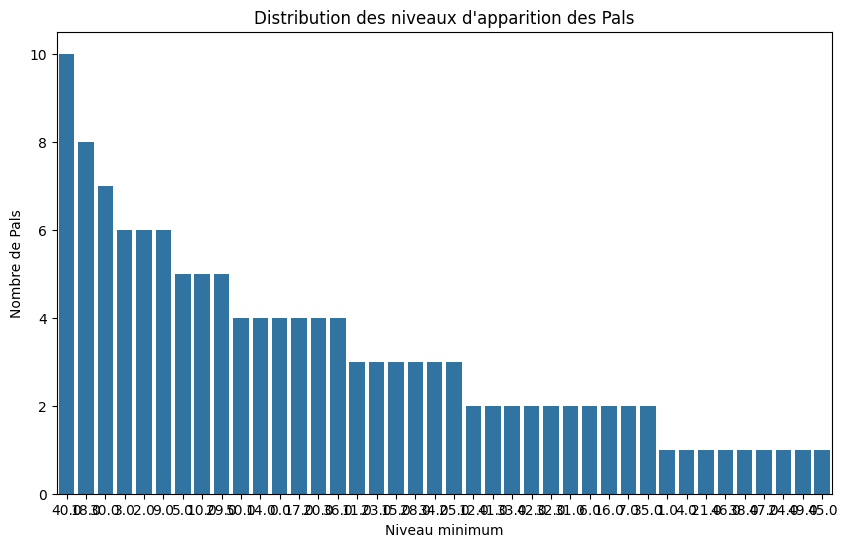

In [ ]:

# Charger les données
refresh_level = pd.read_csv('data/Palworld_Data--Palu refresh level.csv')

# Normaliser les noms de colonnes
refresh_level.columns = [col.strip().lower().replace(' ', '_') for col in refresh_level.columns]

# Vérifier les colonnes
print(refresh_level.columns)

# Distribution des niveaux d'apparition
plt.figure(figsize=(10, 6))
sns.countplot(data=refresh_level, x='minimum_level', order=refresh_level['minimum_level'].value_counts().index)
plt.title('Distribution des niveaux d\'apparition des Pals')
plt.xlabel('Niveau minimum')
plt.ylabel('Nombre de Pals')
plt.show()


### a. Distribution de la taille des Pals

Index(['id', 'chinese_name', 'name', 'codename', 'overridenametextid',
       'nameprefixid', 'overridepartnerskilltextid', 'ispal', 'tribe',
       'bpclass', 'variant', 'volume_size', 'rarity', 'element_1', 'element_2',
       'genuscategory', 'organization', 'weapon', 'weaponequip', 'nocturnal',
       '4d_total', 'hp', 'melee_attack', 'remote_attack', 'defense', 'support',
       'speed_of_work', 'level_1', 'level_20', 'level_50', 'airresponse',
       'aisightresponse', 'endurance', 'slow_walking_speed', 'walking_speed',
       'running_speed', 'riding_sprint_speed', '(being)_damage_multiplier',
       'catch_rate', 'experience_multiplier', 'price', 'must_bring_entry_1',
       'must_bring_entry_2', 'numerical_description', 'lv1', 'lv2', 'lv3',
       'lv4', 'lv5', 'skill_description'],
      dtype='object')
volume_size
L     43
M     33
XS    32
S     15
XL    15
Name: count, dtype: int64


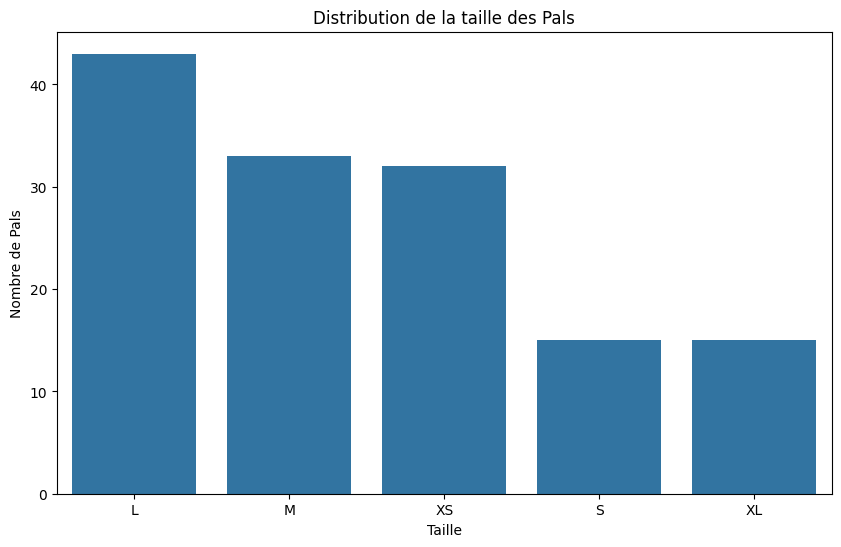

In [ ]:
plt.figure(figsize=(10, 6))
print(combat_attributes.columns)
print(combat_attributes['volume_size'].value_counts())
sns.countplot(data=combat_attributes, x='volume_size', order=combat_attributes['volume_size'].value_counts().index)
plt.title('Distribution de la taille des Pals')
plt.xlabel('Taille')
plt.ylabel('Nombre de Pals')
plt.show()


### b. Distribution de la catégorie des Pals

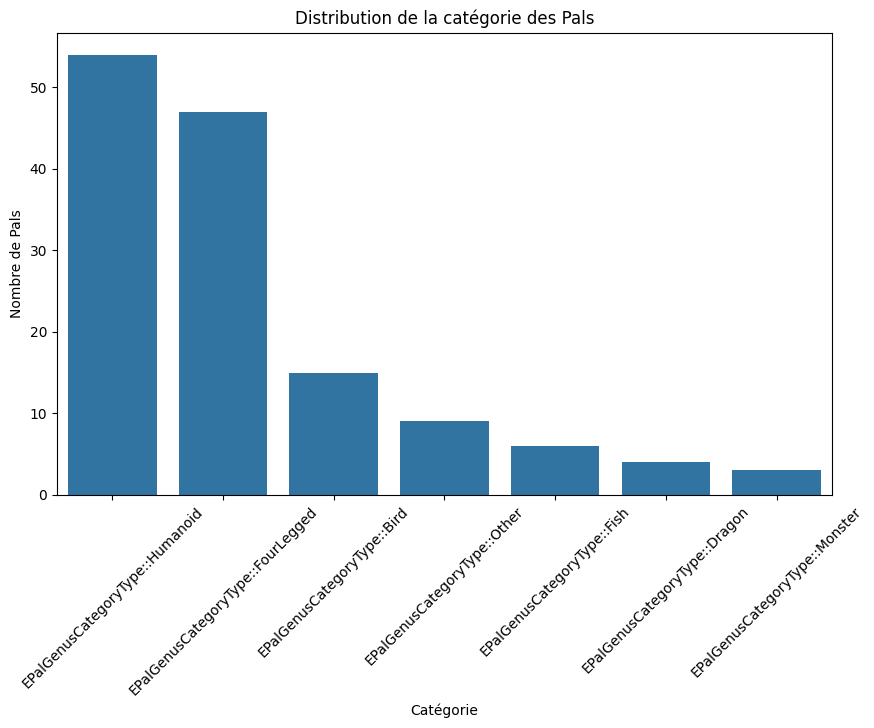

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=combat_attributes, x='genuscategory', order=combat_attributes['genuscategory'].value_counts().index)
plt.title('Distribution de la catégorie des Pals')
plt.xlabel('Catégorie')
plt.ylabel('Nombre de Pals')
plt.xticks(rotation=45)
plt.show()


 ### c.Distribution des points de vie des Pals


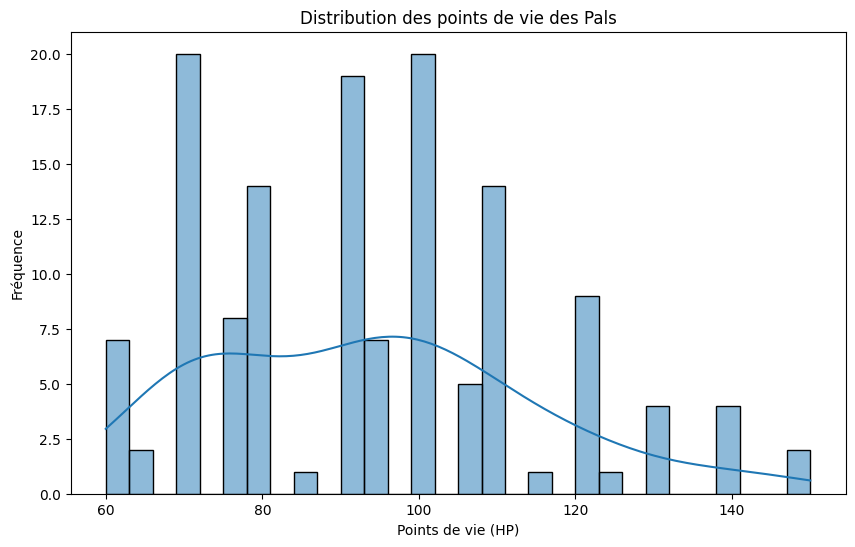

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(combat_attributes['hp'], bins=30, kde=True)
plt.title('Distribution des points de vie des Pals')
plt.xlabel('Points de vie (HP)')
plt.ylabel('Fréquence')
plt.show()


### d. Distribution de la rareté des Pals


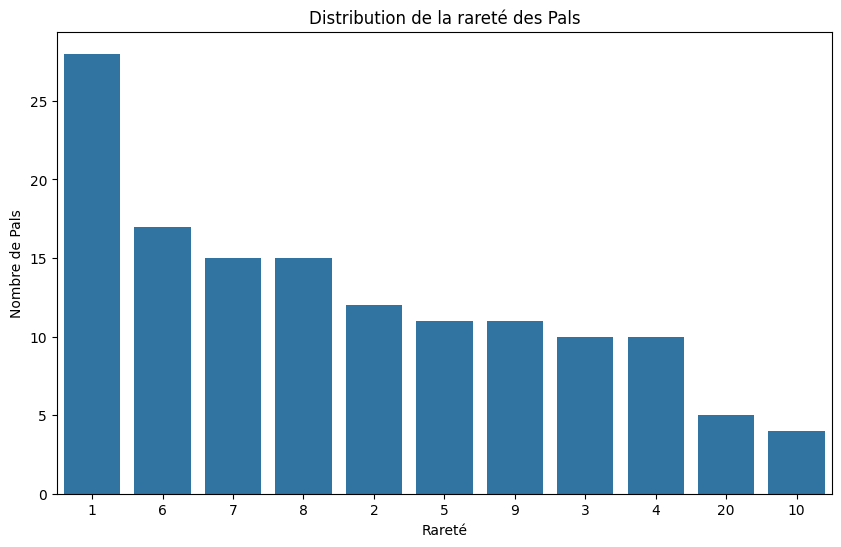

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=combat_attributes, x='rarity', order=combat_attributes['rarity'].value_counts().index)
plt.title('Distribution de la rareté des Pals')
plt.xlabel('Rareté')
plt.ylabel('Nombre de Pals')
plt.show()


### e. Distribution de la consommation alimentaire des Pals

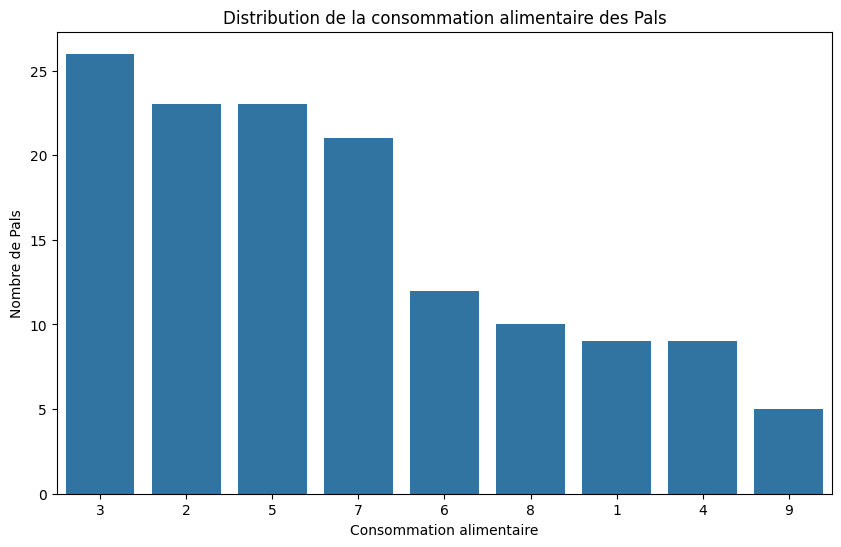

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=job_skills, x='food_intake', order=job_skills['food_intake'].value_counts().index)
plt.title('Distribution de la consommation alimentaire des Pals')
plt.xlabel('Consommation alimentaire')
plt.ylabel('Nombre de Pals')
plt.show()


### f. Pals pouvant offrir des produits utiles à votre campement

In [ ]:
ranch_items = combat_attributes[combat_attributes['must_bring_entry_1'].notnull() | combat_attributes['must_bring_entry_2'].notnull()]
print(ranch_items[['name', 'must_bring_entry_1', 'must_bring_entry_2']])


                 name    must_bring_entry_1 must_bring_entry_2
1             Cattiva                 timid                NaN
58            Gorirat                 rough                NaN
79           Digtoise             hard skin                NaN
81           Lovander  Uncharacteristically                NaN
101        Relaxaurus                Greedy                NaN
114           Warsect             hard skin                NaN
118          Blazamut           Emperor Yan                NaN
120           Astegon             hard skin                NaN
122            Anubis                 Yandi                NaN
123        Jormuntide               Neptune                NaN
128            Lyleen              Elf King                NaN
131            Orserk       Thunder Emperor                NaN
133          Paladius                legend           holy day
134          Necromus                legend              Hades
135       Frostallion                legend           i

### g. Liste des 10 Pals les plus puissants


In [ ]:
top_10_pals = combat_attributes.nlargest(10, 'melee_attack')
print(top_10_pals[['name', 'melee_attack', 'defense']])


                 name  melee_attack  defense
46          Incineram           150       85
47     Incineram Noct           150       85
118          Blazamut           150      120
123        Jormuntide           150      100
124  Jormuntide Ignis           150      100
98           Cryolinx           140      110
54           Loupmoon           130       80
122            Anubis           130      100
132        Shadowbeak           130      140
55           Galeclaw           120       60


### h. Corrélations entre les différents attributs de combat

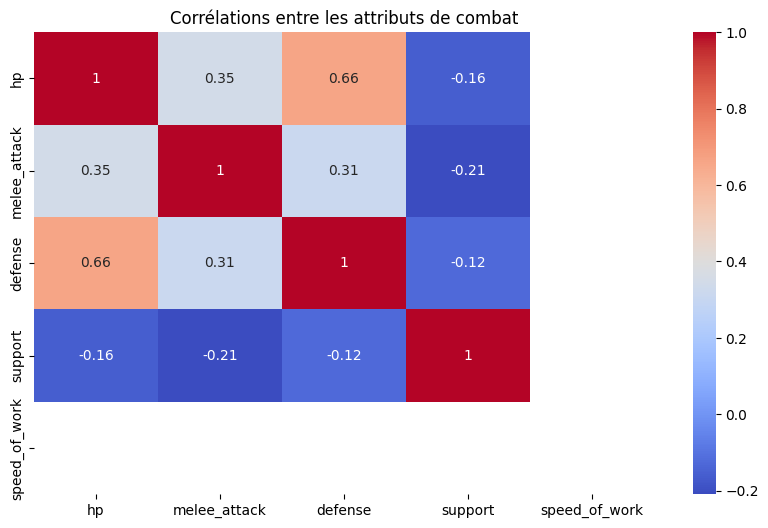

In [ ]:
correlation_matrix = combat_attributes[['hp', 'melee_attack', 'defense', 'support', 'speed_of_work']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Corrélations entre les attributs de combat')
plt.show()


### i. Impact de la rareté sur les valeurs des attributs de base

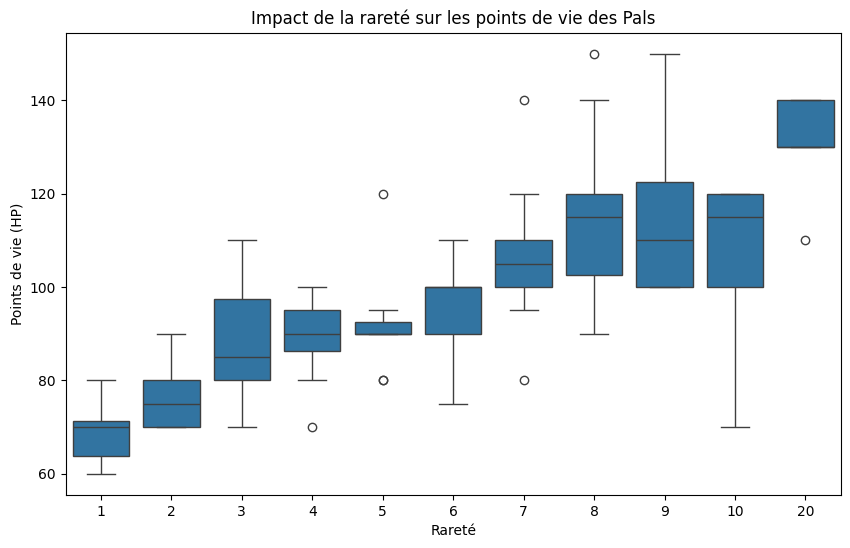

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combat_attributes, x='rarity', y='hp')
plt.title('Impact de la rareté sur les points de vie des Pals')
plt.xlabel('Rareté')
plt.ylabel('Points de vie (HP)')
plt.show()


### j. Rareté moyenne des Pals avec la puissance d'attaque la plus élevée

In [ ]:
max_attack = combat_attributes['melee_attack'].max()
mean_rarity = combat_attributes.loc[combat_attributes['melee_attack'] == max_attack, 'rarity'].mean()
print(f'Rareté moyenne des Pals avec la puissance d\'attaque la plus élevée : {mean_rarity}')


Rareté moyenne des Pals avec la puissance d'attaque la plus élevée : 7.0


### k. Taille des Pals et performance au combat


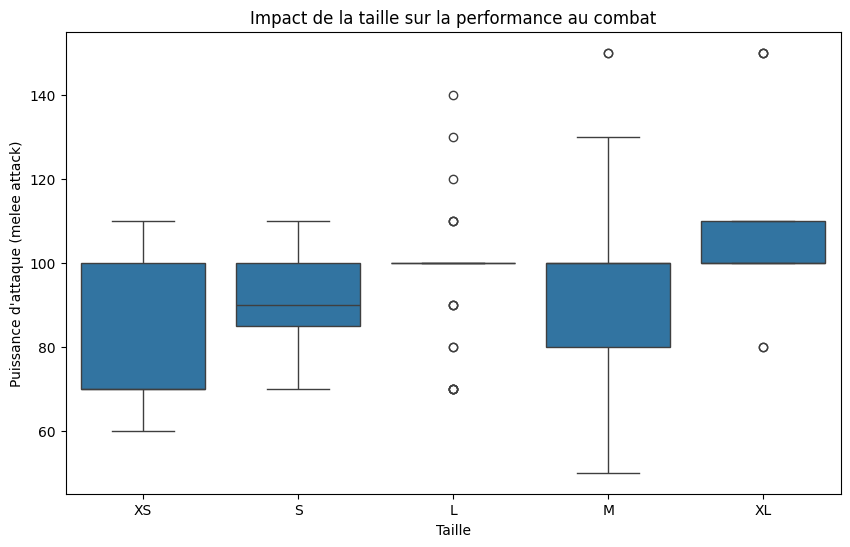

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combat_attributes, x='volume_size', y='melee_attack')
plt.title('Impact de la taille sur la performance au combat')
plt.xlabel('Taille')
plt.ylabel('Puissance d\'attaque (melee attack)')
plt.show()


### l. Rapidité des Pals et efficacité au combat

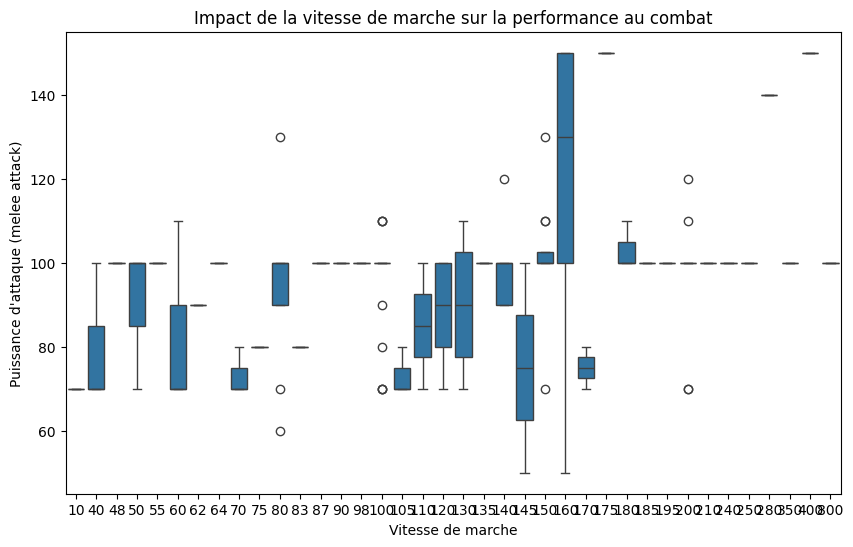

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=combat_attributes, x='walking_speed', y='melee_attack')
plt.title('Impact de la vitesse de marche sur la performance au combat')
plt.xlabel('Vitesse de marche')
plt.ylabel('Puissance d\'attaque (melee attack)')
plt.show()


### m. Équipe équilibrée de 5 Pals

In [ ]:
# Exemple d'équipe équilibrée
balanced_team = combat_attributes.nlargest(5, 'melee_attack')
print(balanced_team[['name', 'melee_attack', 'defense', 'support']])


                 name  melee_attack  defense  support
46          Incineram           150       85      100
47     Incineram Noct           150       85      100
118          Blazamut           150      120       50
123        Jormuntide           150      100      100
124  Jormuntide Ignis           150      100      100


### n. Compétences de travail les plus répandues

In [ ]:
most_common_skills = job_skills['total_skills'].value_counts().head(10)
print(most_common_skills)


total_skills
3     27
1     22
4     20
2     19
5     14
6     13
9      7
10     5
8      5
7      3
Name: count, dtype: int64


### o. Compétences de travail les moins répandues

In [ ]:
least_common_skills = job_skills['total_skills'].value_counts().tail(10)
print(least_common_skills)


total_skills
4     20
2     19
5     14
6     13
9      7
10     5
8      5
7      3
12     2
11     1
Name: count, dtype: int64


### p. Nombre de Pals convenant au travail de nuit

In [ ]:
night_work_pals = job_skills[job_skills['night_shift'] == True]
print(f'Nombre de Pals convenant au travail de nuit : {len(night_work_pals)}')


Nombre de Pals convenant au travail de nuit : 0


### q. Caractéristiques communes des Pals convenant au travail de nuit

In [ ]:
common_night_pals = night_work_pals.describe()
print(common_night_pals)


        id  food_intake  total_skills  make_a_fire  watering  planting  \
count  0.0          0.0           0.0          0.0       0.0       0.0   
mean   NaN          NaN           NaN          NaN       NaN       NaN   
std    NaN          NaN           NaN          NaN       NaN       NaN   
min    NaN          NaN           NaN          NaN       NaN       NaN   
25%    NaN          NaN           NaN          NaN       NaN       NaN   
50%    NaN          NaN           NaN          NaN       NaN       NaN   
75%    NaN          NaN           NaN          NaN       NaN       NaN   
max    NaN          NaN           NaN          NaN       NaN       NaN   

       generate_electricity  manual  collection  logging  mining  \
count                   0.0     0.0         0.0      0.0     0.0   
mean                    NaN     NaN         NaN      NaN     NaN   
std                     NaN     NaN         NaN      NaN     NaN   
min                     NaN     NaN         NaN      NaN     

### r. Rareté moyenne des Pals avec le plus de compétences

In [ ]:
mean_rarity_skills = job_skills['total_skills'].mean()
print(f'Rareté moyenne des Pals avec le plus de compétences : {mean_rarity_skills}')


Rareté moyenne des Pals avec le plus de compétences : 4.188405797101449


### s. Pals avec la vitesse de travail la plus élevée

In [ ]:
fastest_pals = job_skills.nlargest(10, 'handling_speed')
print(fastest_pals[['english_name', 'handling_speed']])


         english_name  handling_speed
130           Faleris           500.0
122            Anubis           480.0
83            Vanwyrm           475.0
84      Vanwyrm Cryst           475.0
117           Quivern           470.0
81           Lovander           460.0
119         Helzephyr           450.0
56         Robinquill           400.0
57   Robinquill Terra           400.0
86             Beakon           375.0


### t. Pals avec la probabilité de capture la plus élevée

In [ ]:
import pandas as pd
# First, remove the '%' sign from the 'catch_rate' column
combat_attributes['catch_rate'] = combat_attributes['catch_rate'].astype(str).str.replace('%', '', regex=False)

# Then, convert the column to a numerical type (e.g., float)
# Handle potential errors by coercing invalid parsing to NaN
combat_attributes['catch_rate'] = pd.to_numeric(combat_attributes['catch_rate'], errors='coerce')

# Now, sort by the numerical 'catch_rate'
top_10_catch_rate = combat_attributes.sort_values(by='catch_rate', ascending=False).head(10)

# Print the result
print(top_10_catch_rate[['name', 'catch_rate']])

                name  catch_rate
0            Lamball         150
1            Cattiva         150
2            Chikipi         150
15              Vixy         130
17           Teafant         130
19            Cremis         130
14  Gumoss (Special)         130
13            Gumoss         130
11           Jolthog         120
4           Foxparks         110


### u. Ordinary Boss ou Tower Boss avec le score d'attributs de combat le plus élevé

In [ ]:
import pandas as pd
import os

# --- Load the dataframes ---
# Load ordinary_boss (assuming its original structure is row-per-boss, column-per-attribute)
# Use skiprows if needed, based on the actual file content
try:
    ordinary_boss_path = 'Palworld_Data-comparison of ordinary BOSS attributes.csv'
    # Your original code used skiprows=3 for ordinary_boss. Let's keep that.
    ordinary_boss = pd.read_csv(ordinary_boss_path, skiprows=3)
    print(f"Successfully loaded {ordinary_boss_path}")
    print("Ordinary Boss head (after skiprows=3):\n", ordinary_boss.head().to_markdown())

    # Clean column names immediately after loading
    ordinary_boss.columns = [col.strip().lower().replace(' ', '_') for col in ordinary_boss.columns]
    print("Ordinary Boss Columns after initial clean:", ordinary_boss.columns.tolist())


except FileNotFoundError:
    print(f"Error: {ordinary_boss_path} not found.")
    ordinary_boss = None
except Exception as e:
    print(f"Error loading {ordinary_boss_path}: {e}")
    ordinary_boss = None


# Load tower_boss with the clarified structure:
# Column 1       | Column 2    | Column 3    | ...
# ----------------|-------------|-------------|----
# Attribute Name | Boss 1 Name | Boss 2 Name | ... <-- This is the header row we want
# HP             | HP Value 1  | HP Value 2  | ...
# Melee Attack   | MA Value 1  | MA Value 2  | ...
# ...            | ...         | ...         | ...
# fecundity      | Fecundity 1 | Fecundity 2 | ...

try:
    tower_boss_path = 'Palworld_Data-Tower BOSS attribute comparison.csv'
    # Load the file. We need to find the row that contains "Attribute Name", "Boss 1 Name", etc.
    # Let's assume this row is the first row after some possible metadata at the very top.
    # If your original file had metadata lines before this header, use skiprows accordingly.
    # Based on your original code's `skiprows=1` when first loading tower_boss,
    # let's assume the header is on the second row (index 1) of the raw file.
    # We'll load the data *without* skipping the header row initially.

    # Read the raw data, potentially skipping initial metadata (if any, adjust skiprows)
    # Let's try skiprows=0 first and inspect. If the header is at index 1, we'll adjust.
    tower_boss_raw = pd.read_csv(tower_boss_path, skiprows=0, header=None) # Read without setting headers
    print(f"\nSuccessfully loaded {tower_boss_path} raw.")
    print("Raw Tower Boss head:\n", tower_boss_raw.head().to_markdown())


    # Identify the row that contains the actual headers ('Attribute Name', 'Boss 1 Name', ...)
    # Let's assume this row is at index 1 (the second row, since index 0 is the first).
    header_row_index = 0 # Adjust this based on your actual file inspection

    # Get the header row values
    header_values = tower_boss_raw.iloc[header_row_index]

    # Drop the header row from the data
    tower_boss_data = tower_boss_raw.drop(header_row_index)

    # Set the columns of the data using the header values
    tower_boss_data.columns = header_values

    # Set the first column ('Attribute Name') as the index *before* transposing
    attribute_col_name_raw = tower_boss_data.columns[0]
    print(f"\nAssuming '{attribute_col_name_raw}' is the attribute name column.")

    # Drop the original header row value from the index name if it carried over
    # The index name might be the first header value ('Attribute Name') or None
    tower_boss_data.index.name = None # Clear index name before setting index

    # Set the attribute column as the index
    tower_boss = tower_boss_data.set_index(attribute_col_name_raw)


    # Transpose the DataFrame
    tower_boss = tower_boss.T
    print("\nTower Boss after set_index and Transpose:\n", tower_boss.head().to_markdown())
    print("Tower Boss Columns after set_index and Transpose:", tower_boss.columns.tolist())
    print("Tower Boss Index after set_index and Transpose:", tower_boss.index.tolist()) # Index should be original column headers (Boss Names)


    # Now the index contains the Boss Names, and the columns contain the Attributes.
    # Convert the index (Boss Names) into a column named 'name'.
    tower_boss = tower_boss.reset_index()

    # Rename the column created from the index to 'name'.
    # This column is usually named 'index' or the original index name if it had one before reset.
    # Since we cleared the index name before set_index, it should be 'index' or the original raw column name.
    col_to_rename_to_name = tower_boss.columns[0]
    if col_to_rename_to_name != 'name': # Only rename if it's not already 'name'
        tower_boss.rename(columns={col_to_rename_to_name: 'name'}, inplace=True)
        print(f"Renamed column '{col_to_rename_to_name}' to 'name' in tower_boss after reset_index.")
    else:
         print("Column already named 'name' after reset_index.")


    # Clean and standardize the attribute column names (which are now the columns of the DataFrame)
    # These are the values from the original first column ('HP', 'Melee Attack', etc.)
    # Exclude the newly renamed 'name' column from this standardization if it wasn't already standard
    cols_to_standardize = [col for col in tower_boss.columns if col != 'name']
    standardized_cols_map = {col: str(col).strip().lower().replace(' ', '_') for col in cols_to_standardize}
    tower_boss.rename(columns=standardized_cols_map, inplace=True)

    print("\nTower Boss Columns after reset_index and renaming:", tower_boss.columns.tolist())
    print("Tower Boss head after reset_index and renaming:\n", tower_boss.head().to_markdown())


    # Handle potential duplicate column names (less likely now but good practice)
    # Check for duplicates *after* all renaming
    duplicate_cols = tower_boss.columns[tower_boss.columns.duplicated()].unique()
    if len(duplicate_cols) > 0:
        print(f"\nDuplicate columns found in tower_boss after processing: {duplicate_cols}")
        print("Dropping duplicate columns, keeping the first occurrence.")
        # Ensure we keep the 'name' column even if it was a duplicate (shouldn't happen with the above steps)
        tower_boss = tower_boss.loc[:, ~tower_boss.columns.duplicated(keep='first')].copy() # Use .copy()
        print("Tower Boss Columns after dropping duplicates:", tower_boss.columns.tolist())
    else:
         print("\nNo duplicate columns found in tower_boss after processing.")


    print("\nFinal Processed Tower Boss Columns:", tower_boss.columns.tolist())
    print("Final Processed Tower Boss head:\n", tower_boss.head().to_markdown())


except FileNotFoundError:
    print(f"Error: {tower_boss_path} not found.")
    tower_boss = None
except Exception as e:
    print(f"Error processing {tower_boss_path}: {e}")
    print("Please check the structure of the original CSV file and the 'header_row_index'.")
    tower_boss = None


# --- Sauvegarder les données nettoyées ---
# Ensure the output directory exists
output_directory = 'data'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)


# Save the processed DataFrames
if ordinary_boss is not None:
    ordinary_boss_save_path = os.path.join(output_directory, 'Palworld_Data-comparison of ordinary BOSS attributes.csv')
    try:
        # Ensure consistent naming before saving
        ordinary_boss.columns = [col.strip().lower().replace(' ', '_') for col in ordinary_boss.columns]
        ordinary_boss.to_csv(ordinary_boss_save_path, index=False)
        print(f"\nSuccessfully saved cleaned ordinary_boss to {ordinary_boss_save_path}")
    except Exception as e:
        print(f"Error saving ordinary_boss to CSV: {e}")

if tower_boss is not None:
    tower_boss_save_path = os.path.join(output_directory, 'Palworld_Data-Tower BOSS attribute comparison.csv')
    try:
        # Check state before saving
        print("\n--- State of tower_boss just before saving ---")
        print("Tower Boss Index:", tower_boss.index)
        print("Tower Boss Index Name:", tower_boss.index.name)
        print("Tower Boss Columns:", tower_boss.columns.tolist())
        print("Tower Boss head:\n", tower_boss.head().to_markdown())
        print("-------------------------------------------")

        tower_boss.to_csv(tower_boss_save_path, index=False)
        print(f"\nSuccessfully saved cleaned tower_boss to {tower_boss_save_path}")

        # Optional: Verify by reading it back
        print(f"Verifying saved file by reading from {tower_boss_save_path}...")
        tower_boss_reloaded = pd.read_csv(tower_boss_save_path)
        print("Reloaded tower_boss columns:", tower_boss_reloaded.columns.tolist())
        print("Reloaded tower_boss head:\n", tower_boss_reloaded.head().to_markdown())

    except Exception as e:
        print(f"Error saving tower_boss to CSV: {e}")

# --- Continue with Concatenation and Analysis (Optional) ---
# If you want to concatenate the two boss lists for finding highest stats:
if ordinary_boss is not None and tower_boss is not None:
    print("\nConcatenating ordinary_boss and tower_boss for combined analysis...")

    # Ensure columns needed for analysis have consistent names across both DataFrames
    # 'name', 'hp', 'melee_attack', 'defense' should be present in both after cleaning above.
    # If other columns exist in one but not the other, pd.concat will handle them (NaNs).

    try:
        highest_boss = pd.concat([ordinary_boss, tower_boss], ignore_index=True, sort=False)
        print("Concatenation successful.")
        print("Concatenated Bosses Columns:", highest_boss.columns.tolist())
        # print("Concatenated Bosses head:\n", highest_boss.head()) # Optional print

        # --- Convert relevant columns to numeric ---
        # List all attribute columns you expect to be numeric
        all_attribute_cols = [
            'hp', 'melee_attack', 'remote_attack', 'defense', 'support',
            'experience_ratio', 'slow_walking_speed', 'walking_speed',
            'running_speed', 'riding_speed', 'handling_speed',
            'ignore_the_bluntness', 'ignore_displacement', 'biologicalgrade',
            'endurance', 'fecundity'
        ]
        combat_cols_to_convert = [col for col in all_attribute_cols if col in highest_boss.columns] # Only try to convert columns that exist


        print(f"\nConverting combat and attribute columns {combat_cols_to_convert} to numeric...")
        for col in combat_cols_to_convert:
            if col in highest_boss.columns:
                # Check data types before conversion
                # print(f"Column '{col}' dtype before conversion: {highest_boss[col].dtype}") # Optional print
                # Convert to numeric, coercing errors to NaN
                # Handle potential non-numeric characters like commas or '%' if they exist
                if highest_boss[col].dtype == 'object': # Only attempt string manipulation if it's an object/string type
                    highest_boss[col] = highest_boss[col].astype(str).str.replace(',', '', regex=False).str.replace('%', '', regex=False)
                highest_boss[col] = pd.to_numeric(highest_boss[col], errors='coerce')
                # print(f"Column '{col}' dtype after conversion: {highest_boss[col].dtype}") # Optional print
                # Fill NaN with 0 after conversion if appropriate for analysis
                # highest_boss[col].fillna(0, inplace=True) # Uncomment if you want to treat missing combat stats as 0
            else:
                # This else should theoretically not be hit because we filter combat_cols_to_convert
                pass

        # --- Add print statements to diagnose HP issue ---
        print("\n--- Debugging HP Comparison ---")
        print("Columns in highest_boss after numeric conversion:", highest_boss.columns.tolist())
        if 'hp' in highest_boss.columns:
            print(f"Data type of 'hp' column: {highest_boss['hp'].dtype}")
            print("First 5 values of 'hp' column:", highest_boss['hp'].head())
            print(f"Number of non-NaN values in 'hp': {highest_boss['hp'].notna().sum()}")
        else:
            print("'hp' column not found in highest_boss.")
        # --- Select only the desired columns for final analysis/output ---
        # Use the comprehensive list of desired columns
        final_analysis_cols = [
            'name',"name.2" ,'hp', 'melee_attack', 'remote_attack', 'defense'
            # Add any other columns you want to keep from either dataframe
        ]

        # Filter for columns that actually exist in the concatenated dataframe
        final_analysis_cols_present = [col for col in final_analysis_cols if col in highest_boss.columns]

        if len(final_analysis_cols_present) > 0:
             # Select and reorder columns as desired
             highest_boss_analysis = highest_boss[final_analysis_cols_present].copy()

             print("\nDataFrame for analysis with desired columns:")
             print(highest_boss_analysis.head().to_markdown())
             print("\nAnalysis DataFrame Columns:", highest_boss_analysis.columns.tolist())
             # --- Add print statements to diagnose HP issue in analysis DataFrame ---
             print("\n--- Debugging HP Comparison in Analysis DataFrame ---")
             print("Columns in highest_boss_analysis:", highest_boss_analysis.columns.tolist())
             if 'hp' in highest_boss_analysis.columns:
                print(f"Data type of 'hp' column in highest_boss_analysis: {highest_boss_analysis['hp'].dtype}")
                print("First 5 values of 'hp' in highest_boss_analysis:", highest_boss_analysis['hp'].head())
                print(f"Number of non-NaN values in 'hp' in highest_boss_analysis: {highest_boss_analysis['hp'].notna().sum()}")
             else:
                 print("'hp' column not found in highest_boss_analysis.")


             # --- Find Bosses with Highest Stats from the analysis DataFrame ---
             print("\nFinding Bosses with Highest Stats from analysis data...")

             # Ensure the key columns for finding highest stats are present
             # Check based on the columns *in the analysis DataFrame*
             stats_cols_for_nlargest = [col for col in ['hp', 'melee_attack', 'defense'] if col in highest_boss_analysis.columns]
             print(f"Columns considered for nlargest: {stats_cols_for_nlargest}") # <-- Check this list


             if 'hp' in stats_cols_for_nlargest:
                 highest_hp_boss = highest_boss_analysis.nlargest(1, 'hp', keep='all') # Use keep='all' to get all rows if multiple have the same max value
                 print("\nHighest HP Boss(es):")
                 print(highest_hp_boss.to_markdown(index=False))

             if 'defense' in stats_cols_for_nlargest:
                 highest_defense_boss = highest_boss_analysis.nlargest(1, 'defense', keep='all')
                 print("\nHighest Defense Boss(es):")
                 print(highest_defense_boss.to_markdown(index=False))

             if 'melee_attack' in stats_cols_for_nlargest:
                  highest_melee_boss = highest_boss_analysis.nlargest(1, 'melee_attack', keep='all')
                  print("\nHighest Melee Attack Boss(es):")
                  print(highest_melee_boss.to_markdown(index=False))

        else:
             print("\nNone of the desired final analysis columns were found in the concatenated data.")


    except Exception as e:
        print(f"\nAn error occurred during concatenation or analysis: {e}")
        print("Please review the dataframe structures and column names.")
        print("Ordinary Boss Columns:", ordinary_boss.columns.tolist() if ordinary_boss is not None else "ordinary_boss is None")
        print("Tower Boss Columns:", tower_boss.columns.tolist() if tower_boss is not None else "tower_boss is None")

Successfully loaded Palworld_Data-comparison of ordinary BOSS attributes.csv
Ordinary Boss head (after skiprows=3):
 |    | name                     |   HP |   0.0 | name.1            |   Remote attack |   0.0.1 | name.2        |   Riding speed (BOSS is 100 higher) |
|---:|:-------------------------|-----:|------:|:------------------|----------------:|--------:|:--------------|------------------------------------:|
|  0 | Chaos Knight BOSS        |  260 |     0 | Melupa BOSS       |              90 |       0 | Zixialu BOSS  |                                1000 |
|  1 | Chaos Knight             |  130 |     0 | Melupa            |              75 |       0 | Zixia Deer    |                                 900 |
|  2 | Winter Caller Beast BOSS |  420 |     0 | Volt Meow BOSS    |              80 |       0 | Suzaku BOSS   |                                1200 |
|  3 | Winter Caller            |  140 |     0 | Volt Meow         |              75 |       0 | Suzaku        |                

### v. Répartition des niveaux d'apparition des Pals

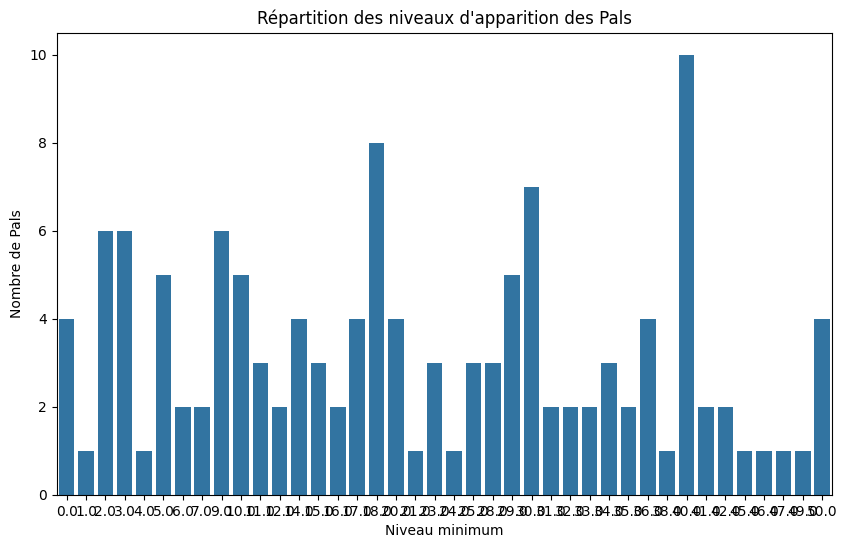

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=refresh_level, x='minimum_level')
plt.title('Répartition des niveaux d\'apparition des Pals')
plt.xlabel('Niveau minimum')
plt.ylabel('Nombre de Pals')
plt.show()


### w. Répartition des zones d'apparition

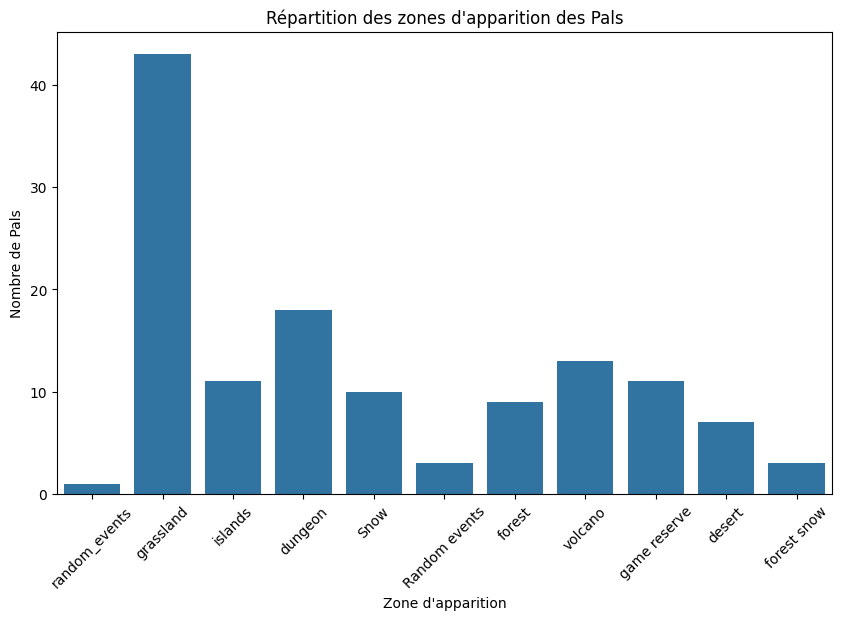

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=refresh_level, x='refresh_area')
plt.title('Répartition des zones d\'apparition des Pals')
plt.xlabel('Zone d\'apparition')
plt.ylabel('Nombre de Pals')
plt.xticks(rotation=45)
plt.show()
